# 02 — Process Structure
Understand the shape of the process before applying discovery algorithms.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
from src.load_event_log import load_xes_log, convert_to_dataframe
from src.process_summary import get_case_durations, get_activity_frequency, get_variants

DATA_PATH = Path('../data/raw/PermitLog.xes')
FIGURES_OUT = Path('../outputs/figures')
TABLES_OUT = Path('../outputs/tables')
FIGURES_OUT.mkdir(parents=True, exist_ok=True)
TABLES_OUT.mkdir(parents=True, exist_ok=True)

In [2]:
log = load_xes_log(DATA_PATH)
df = convert_to_dataframe(log)
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], utc=True)
print(f'{len(df)} events, {df["case:concept:name"].nunique()} cases')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 7065/7065 [00:00<00:00, 8931.02it/s] 


86581 events, 7065 cases


## 1. Activity frequency

In [3]:
act_freq = get_activity_frequency(df)
act_freq.to_csv(TABLES_OUT / 'activity_frequency.csv', index=False)
act_freq

,activity,count,pct
0,Declaration SUBMITTED by EMPLOYEE,7574,8.75
1,Payment Handled,7544,8.71
2,Request Payment,7541,8.71
3,Permit SUBMITTED by EMPLOYEE,7331,8.47
4,Start trip,7065,8.16
5,End trip,7065,8.16
6,Permit FINAL_APPROVED by SUPERVISOR,6300,7.28
7,Permit APPROVED by ADMINISTRATION,5715,6.60
8,Declaration FINAL_APPROVED by SUPERVISOR,5641,6.52
9,Declaration APPROVED by ADMINISTRATION,4782,5.52


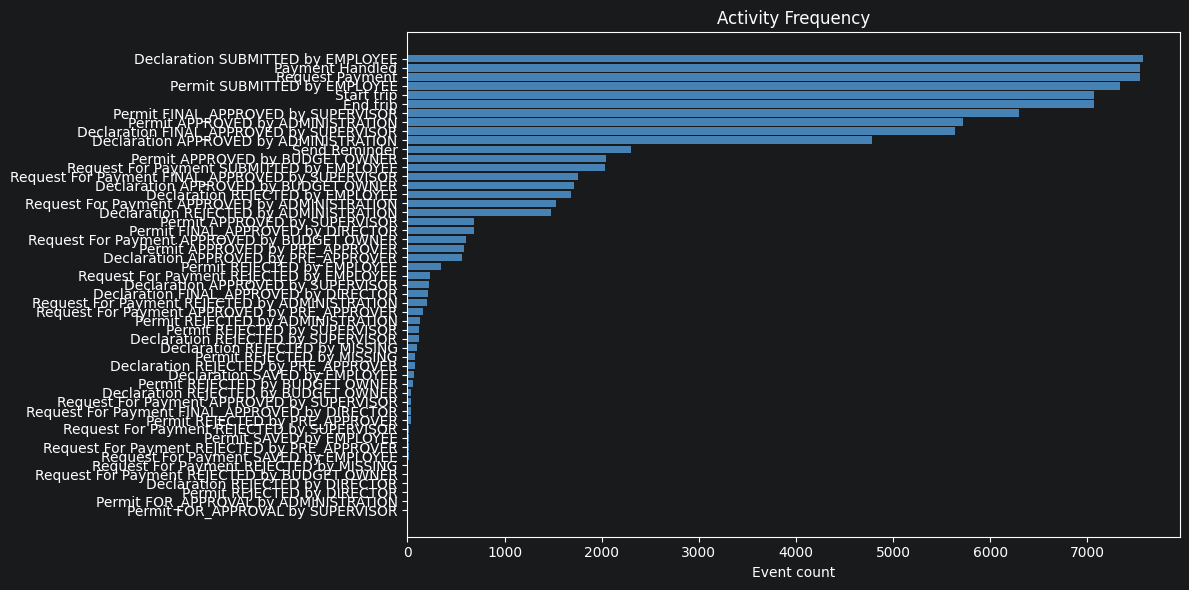

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(act_freq['activity'], act_freq['count'], color='steelblue')
ax.set_xlabel('Event count')
ax.set_title('Activity Frequency')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIGURES_OUT / 'activity_frequency.png', dpi=150)
plt.show()

## 2. Start and end activities

In [5]:
case_col = 'case:concept:name'
time_col = 'time:timestamp'
act_col = 'concept:name'

df_sorted = df.sort_values([case_col, time_col])
start_acts = df_sorted.groupby(case_col)[act_col].first().value_counts().reset_index()
start_acts.columns = ['activity', 'count']
end_acts = df_sorted.groupby(case_col)[act_col].last().value_counts().reset_index()
end_acts.columns = ['activity', 'count']

print('Start activities:')
print(start_acts.to_string(index=False))
print()
print('End activities:')
print(end_acts.to_string(index=False))

start_acts.to_csv(TABLES_OUT / 'start_activities.csv', index=False)
end_acts.to_csv(TABLES_OUT / 'end_activities.csv', index=False)

Start activities:
                    activity  count
Permit SUBMITTED by EMPLOYEE   6319
                  Start trip    734
    Permit SAVED by EMPLOYEE     12

End activities:
                           activity  count
                    Payment Handled   5474
                      Send Reminder    991
                           End trip    453
         Permit REJECTED by MISSING     38
        Permit REJECTED by EMPLOYEE     31
      Declaration SAVED by EMPLOYEE     28
   Declaration REJECTED by EMPLOYEE     28
Permit FINAL_APPROVED by SUPERVISOR     14
           Permit SAVED by EMPLOYEE      4
    Declaration REJECTED by MISSING      2
                    Request Payment      1
 Declaration REJECTED by SUPERVISOR      1


## 3. Case duration statistics

In [6]:
durations = get_case_durations(df)
print(durations['duration_days'].describe())
durations.to_csv(TABLES_OUT / 'case_durations.csv', index=False)

count    7065.000000
mean       87.390191
std        65.835204
min         0.525370
25%        40.885926
50%        71.730012
75%       117.243461
max      1190.328715
Name: duration_days, dtype: float64


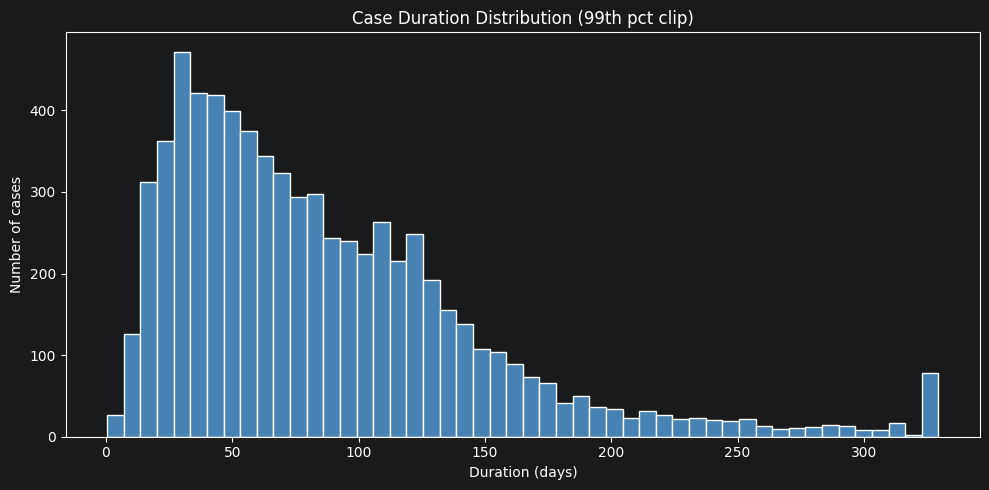

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(durations['duration_days'].clip(upper=durations['duration_days'].quantile(0.99)), bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Duration (days)')
ax.set_ylabel('Number of cases')
ax.set_title('Case Duration Distribution (99th pct clip)')
plt.tight_layout()
fig.savefig(FIGURES_OUT / 'case_duration_distribution.png', dpi=150)
plt.show()

## 4. Events per case distribution

count    7065.000000
mean       12.254919
std         5.585228
min         3.000000
25%         9.000000
50%        11.000000
75%        15.000000
max        90.000000
dtype: float64


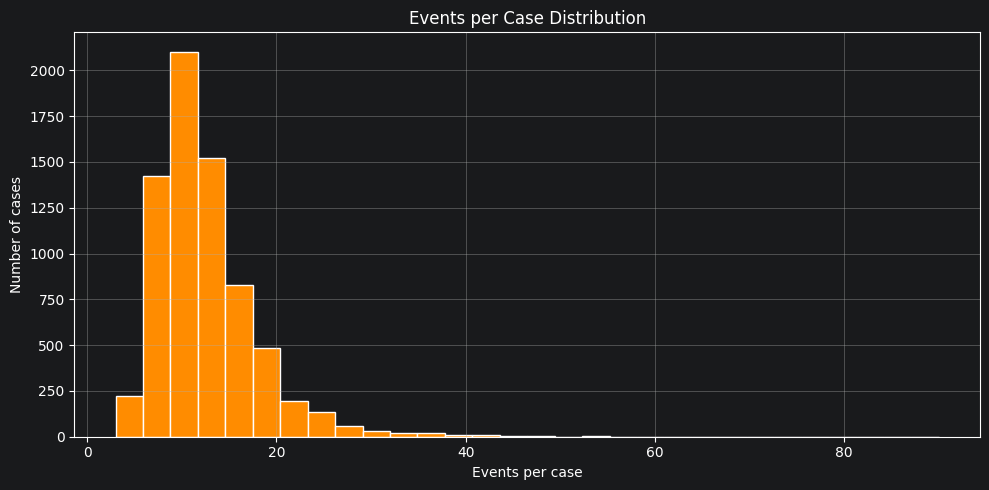

In [8]:
events_per_case = df.groupby(case_col).size()
print(events_per_case.describe())

fig, ax = plt.subplots(figsize=(10, 5))
events_per_case.hist(bins=30, ax=ax, color='darkorange', edgecolor='white')
ax.set_xlabel('Events per case')
ax.set_ylabel('Number of cases')
ax.set_title('Events per Case Distribution')
plt.tight_layout()
fig.savefig(FIGURES_OUT / 'events_per_case.png', dpi=150)
plt.show()

## 5. Process variants — top 20

In [9]:
variants = get_variants(df)
print(f'Total unique variants: {len(variants)}')
variants.to_csv(TABLES_OUT / 'variants.csv', index=False)
variants.head(20)

Total unique variants: 1478


,variant,case_count,pct
0,Permit SUBMITTED by EMPLOYEE -> Permit APPROVE...,956,13.53
1,Permit SUBMITTED by EMPLOYEE -> Permit APPROVE...,427,6.04
2,Permit SUBMITTED by EMPLOYEE -> Permit APPROVE...,343,4.85
3,Permit SUBMITTED by EMPLOYEE -> Permit FINAL_A...,302,4.27
4,Permit SUBMITTED by EMPLOYEE -> Permit APPROVE...,243,3.44
5,Permit SUBMITTED by EMPLOYEE -> Permit APPROVE...,201,2.85
6,Permit SUBMITTED by EMPLOYEE -> Permit APPROVE...,166,2.35
7,Start trip -> End trip -> Permit SUBMITTED by ...,148,2.09
8,Permit SUBMITTED by EMPLOYEE -> Permit APPROVE...,147,2.08
9,Permit SUBMITTED by EMPLOYEE -> Permit APPROVE...,138,1.95


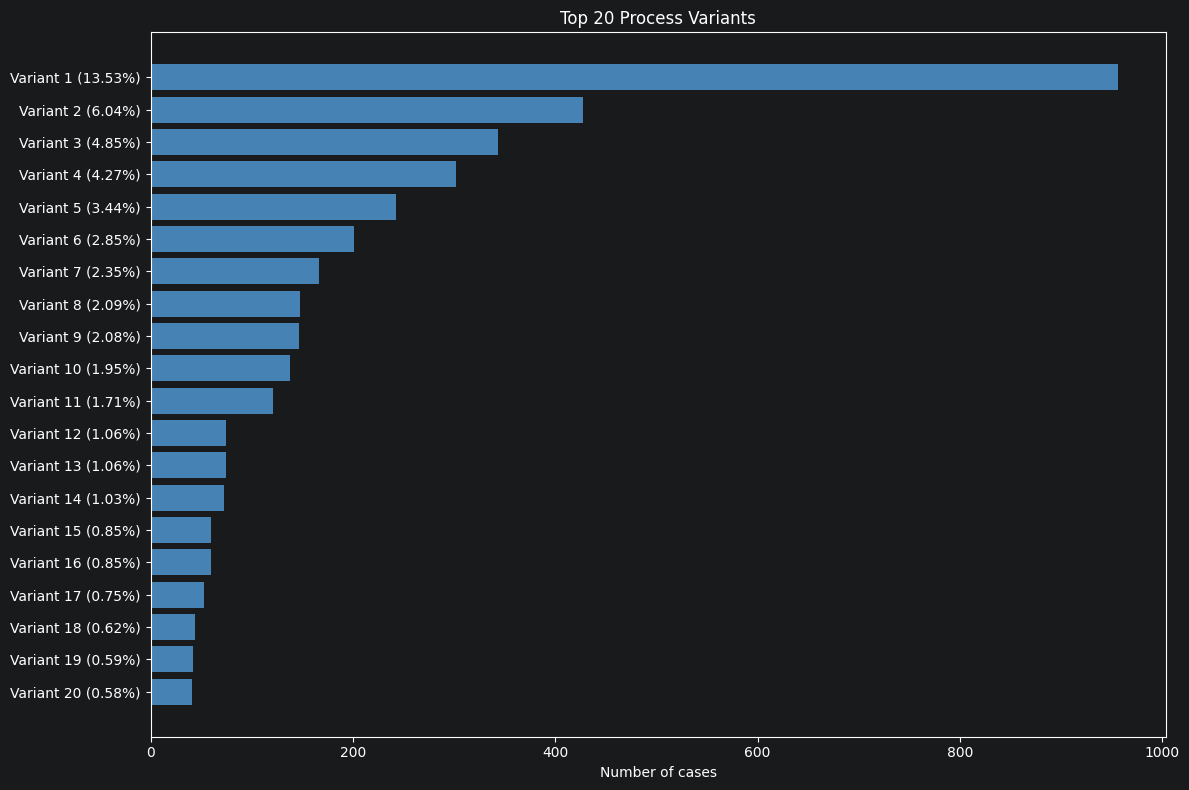

In [10]:
top20 = variants.head(20)
fig, ax = plt.subplots(figsize=(12, 8))
labels = [f'Variant {i+1} ({row.pct}%)' for i, row in top20.iterrows()]
ax.barh(labels, top20['case_count'], color='steelblue')
ax.set_xlabel('Number of cases')
ax.set_title('Top 20 Process Variants')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIGURES_OUT / 'top20_variants.png', dpi=150)
plt.show()